# 05 · Selección del estudiante

El producto final es una aplicación web que corre el modelo **en el dispositivo
del usuario**, así que el costo que manda es lo que el navegador tiene que
descargar, no los milisegundos en una CPU de escritorio.

**Criterio: el mejor macro-F1 que quepa en `PRESUPUESTO_MB`.** El presupuesto
es una decisión de producto, no un óptimo: dice cuánta descarga se está
dispuesto a imponerle al usuario en la primera carga.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "corpus.json").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Raíz del proyecto:", ROOT)

Raíz del proyecto: /Users/cristiansandoval/Universidad/Semillero/ButterflyModeling


In [2]:
import pandas as pd
import tensorflow as tf

from scripts import evalStats
from scripts import modelRegistry as registro
from scripts.architectures import ESTUDIANTES
from scripts.vizStyle import INK_MUTED, SERIE_1, SERIE_2, SERIE_3, applyStyle

ROL = "estudiante"

# pesos en float32 que descarga el navegador; int8 divide por ~4
PRESUPUESTO_MB = 8.0

# clave (arquitectura, descongelado): congelado y fine-tuning son regímenes
# distintos y ambos deben verse en la tabla, no solo el más reciente
runs = registro.listRuns()
runPorArquitectura = {}
for run in runs:
    arquitectura = run.get("architecture")
    clave = (arquitectura, run.get("finetuning", 0.0))
    if run.get("role") == ROL and arquitectura in ESTUDIANTES and clave not in runPorArquitectura:
        runPorArquitectura[clave] = run

entrenadas = {a for a, _ in runPorArquitectura}
faltantes = [a for a in ESTUDIANTES if a not in entrenadas]
if faltantes:
    print("Sin run registrado todavía:", faltantes)
print(f"{len(entrenadas)} de {len(ESTUDIANTES)} candidatos entrenados, "
      f"{len(runPorArquitectura)} runs en total")

4 de 4 candidatos entrenados, 8 runs en total


## 1 · Calidad y costo de despliegue

`pesos_MB` es lo que realmente se descarga: parámetros x 4 bytes. El archivo
`.keras` no sirve como medida — incluye el estado del optimizador de Adam, que
casi triplica el tamaño y no se despliega.

In [3]:
filas = []
for (arquitectura, descongelado), run in runPorArquitectura.items():
    modelo = tf.keras.models.load_model(registro.runDir(run["run_id"]) / "model.keras")
    parametros = modelo.count_params()
    metricas = registro.loadRunMetrics(run["run_id"])["splits"]["test"]
    filas.append({
        "arquitectura": arquitectura,
        "descongelado": descongelado,
        "test_macro_f1": run["test_macro_f1"],
        "top3": metricas["top3_accuracy"],
        "parametros_M": round(parametros / 1e6, 2),
        "pesos_MB": round(parametros * 4 / 1e6, 1),
        "int8_MB": round(parametros / 1e6, 1),
        "latencia_ms": round(evalStats.medirLatencia(modelo), 1),
        "run_id": run["run_id"],
    })

comparacion = pd.DataFrame(filas).sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
comparacion.drop(columns="run_id")

,arquitectura,descongelado,test_macro_f1,top3,parametros_M,pesos_MB,int8_MB,latencia_ms
0,efficientnet_b0,0.3,0.900388,0.970902,4.88,19.5,4.9,120.2
1,nasnet_mobile,0.3,0.861428,0.951988,4.99,20.0,5.0,259.2
2,mobilenet_v3_small,0.3,0.842630,0.947624,1.41,5.7,1.4,46.5
3,efficientnet_b0,0.0,0.815861,0.960233,4.88,19.5,4.9,113.9
4,mobilenet_v3_small,0.0,0.769148,0.933075,1.41,5.7,1.4,46.6
5,mobilenet_v2,0.0,0.709435,0.905917,3.09,12.4,3.1,65.6
6,nasnet_mobile,0.0,0.597641,0.854510,4.99,20.0,5.0,241.1
7,mobilenet_v2,0.3,0.000376,0.039767,3.09,12.4,3.1,68.0


## 2 · Calidad vs descarga

La latencia se reporta como referencia, pero se midió en CPU de escritorio: en
un navegador sobre WebGL/WASM y un teléfono de gama media es varias veces
mayor. La descarga, en cambio, es la misma en todas partes.

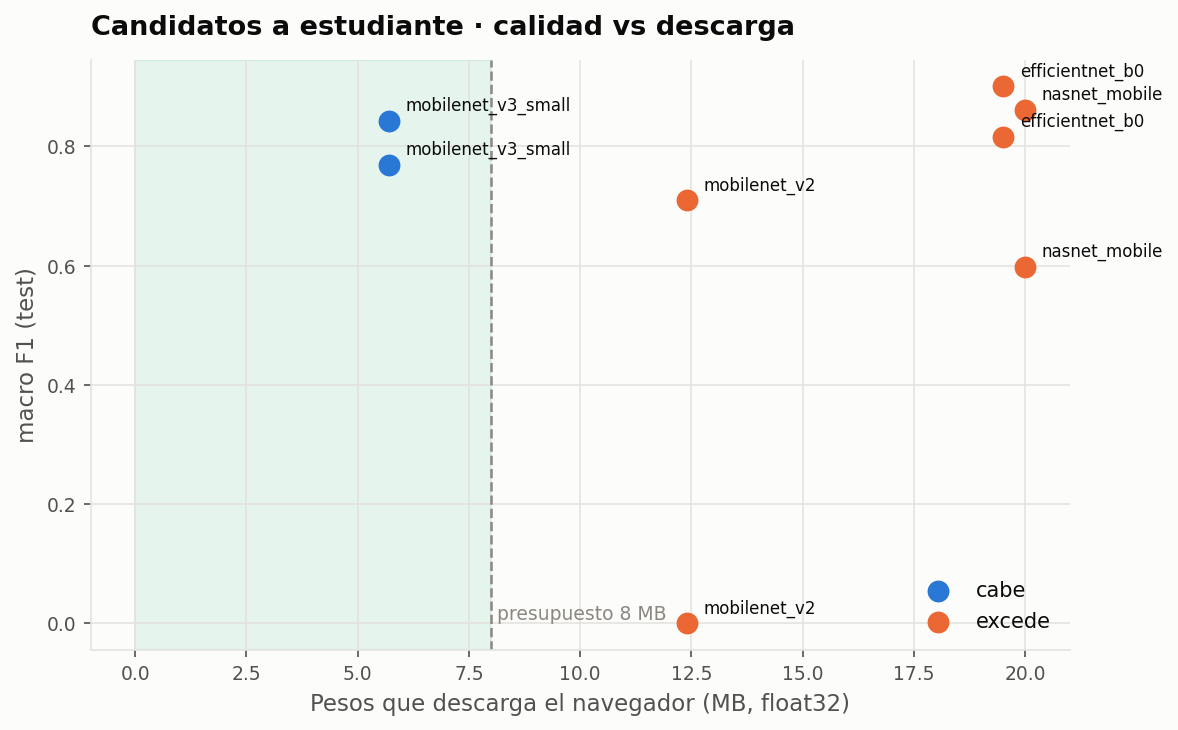

In [4]:
applyStyle()
import matplotlib.pyplot as plt

dentro = comparacion["pesos_MB"] <= PRESUPUESTO_MB

fig, ax = plt.subplots(figsize=(8, 5))
ax.axvspan(0, PRESUPUESTO_MB, color=SERIE_3, alpha=0.10)
ax.axvline(PRESUPUESTO_MB, color=INK_MUTED, linestyle="--", linewidth=1.2)
ax.text(PRESUPUESTO_MB, comparacion["test_macro_f1"].min(), f" presupuesto {PRESUPUESTO_MB:.0f} MB",
        fontsize=9, va="bottom", color=INK_MUTED)
ax.scatter(comparacion.loc[dentro, "pesos_MB"], comparacion.loc[dentro, "test_macro_f1"],
           s=90, color=SERIE_1, label="cabe", zorder=3)
ax.scatter(comparacion.loc[~dentro, "pesos_MB"], comparacion.loc[~dentro, "test_macro_f1"],
           s=90, color=SERIE_2, label="excede", zorder=3)
for _, f in comparacion.iterrows():
    ax.annotate(f["arquitectura"], (f["pesos_MB"], f["test_macro_f1"]),
                textcoords="offset points", xytext=(8, 5), fontsize=8)
ax.set(xlabel="Pesos que descarga el navegador (MB, float32)", ylabel="macro F1 (test)",
       title="Candidatos a estudiante · calidad vs descarga")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

## 3 · Estudiante elegido

In [5]:
candidatos = comparacion[comparacion["pesos_MB"] <= PRESUPUESTO_MB]
if candidatos.empty:
    raise ValueError(f"Ningún candidato cabe en {PRESUPUESTO_MB} MB")

elegido = candidatos.sort_values("test_macro_f1", ascending=False).iloc[0]
run = runPorArquitectura[(elegido["arquitectura"], elegido["descongelado"])]

registro.writeJson(registro.OUTPUTS_DIR / "student.json", {
    "run_id": run["run_id"],
    "architecture": elegido["arquitectura"],
    "finetuning": float(elegido["descongelado"]),
    "test_accuracy": float(run["test_accuracy"]),
    "test_macro_f1": float(elegido["test_macro_f1"]),
    "top3_accuracy": float(elegido["top3"]),
    "pesos_MB": float(elegido["pesos_MB"]),
    "latencia_ms": float(elegido["latencia_ms"]),
    "presupuesto_MB": PRESUPUESTO_MB,
})

print(f"Estudiante: {elegido['arquitectura']} (descongelado {elegido['descongelado']}) · "
      f"macro-F1 {elegido['test_macro_f1']:.4f} · top-3 {elegido['top3']:.4f} · "
      f"{elegido['pesos_MB']:.1f} MB")

excluidos = comparacion[comparacion["pesos_MB"] > PRESUPUESTO_MB]
for _, f in excluidos.iterrows():
    if f["test_macro_f1"] > elegido["test_macro_f1"]:
        print(f"  queda fuera {f['arquitectura']}: {f['test_macro_f1'] - elegido['test_macro_f1']:+.4f} "
              f"de macro-F1 y {f['top3'] - elegido['top3']:+.4f} de top-3, "
              f"pero pesa {f['pesos_MB'] / elegido['pesos_MB']:.1f}x más")

Estudiante: mobilenet_v3_small (descongelado 0.3) · macro-F1 0.8426 · top-3 0.9476 · 5.7 MB
  queda fuera efficientnet_b0: +0.0578 de macro-F1 y +0.0233 de top-3, pero pesa 3.4x más
  queda fuera nasnet_mobile: +0.0188 de macro-F1 y +0.0044 de top-3, pero pesa 3.5x más


## Resumen

In [6]:
comparacion.drop(columns='run_id')

,arquitectura,descongelado,test_macro_f1,top3,parametros_M,pesos_MB,int8_MB,latencia_ms
0,efficientnet_b0,0.3,0.900388,0.970902,4.88,19.5,4.9,120.2
1,nasnet_mobile,0.3,0.861428,0.951988,4.99,20.0,5.0,259.2
2,mobilenet_v3_small,0.3,0.842630,0.947624,1.41,5.7,1.4,46.5
3,efficientnet_b0,0.0,0.815861,0.960233,4.88,19.5,4.9,113.9
4,mobilenet_v3_small,0.0,0.769148,0.933075,1.41,5.7,1.4,46.6
5,mobilenet_v2,0.0,0.709435,0.905917,3.09,12.4,3.1,65.6
6,nasnet_mobile,0.0,0.597641,0.854510,4.99,20.0,5.0,241.1
7,mobilenet_v2,0.3,0.000376,0.039767,3.09,12.4,3.1,68.0
